## **Détection du langage offensif en Arabizi**

**Partie 1 – Exploration et prétraitement**

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv("Arabizi-Off_Lang_Dataset.csv")
df.head()
df = df.rename(columns={
    "Text": "text",
    "Generic Class": "label",
    "Dialect": "dialect"
})

df["label"] = df["label"].map({
    "offensive": "Offensive",
    "non-offensive": "Non-Offensive"
})

df["dialect"] = df["dialect"].map({
    "DZ": "Algerian",
    "LB": "Lebanese"
})

df = df.dropna(subset=["text", "label", "dialect"])
df["id"] = range(1, len(df) + 1)

df = df[["id", "text", "label", "dialect"]]
df.head()


,id,text,label,dialect
0,1,Aw enn l ahla men hek hay li btelbesle crop to...,Non-Offensive,Lebanese
1,2,yu2brnee jamelo pepe :p tfeh shu beche3 bas li...,Non-Offensive,Lebanese
2,3,Lea ktir pedophile 😂,Offensive,Lebanese
3,4,Shu hal hmar hayda,Offensive,Lebanese
4,5,Fasharet 3a ra2btak w ra2bit m3almak w ra2bit ...,Non-Offensive,Lebanese


In [ ]:
print("Taille du corpus :", len(df))
print(df["label"].value_counts(normalize=True))
print(df["dialect"].value_counts())
df.sample(5)

Taille du corpus : 7383
label
Non-Offensive    0.793309
Offensive        0.206691
Name: proportion, dtype: float64
dialect
Algerian    4249
Lebanese    3134
Name: count, dtype: int64


,id,text,label,dialect
450,451,@HussainAyoub el diet m2assir 3lek ktir ya 7as...,Non-Offensive,Lebanese
2413,2414,Ana n2ezet hahahhaha,Non-Offensive,Lebanese
4927,4928,mdrr #aziza kon ta3arfii beli demain la rentré...,Non-Offensive,Algerian
2405,2406,mbde ma habet ma tw23t hek mashhad ha ysir,Non-Offensive,Lebanese
17,18,@YaraOkdi @BobFanous @Rheabutts chou khassik e...,Non-Offensive,Lebanese


In [ ]:
#Prétraitement du texte
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # URLs
    text = re.sub(r"@\w+", "", text)             # handles
    text = re.sub(r"[^a-z0-9\s]", " ", text)     # ponctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(preprocess)

**Partie 2 – Modèles classiques**


 Multinomial NB
               precision    recall  f1-score   support

Non-Offensive       0.85      0.97      0.91       879
    Offensive       0.76      0.35      0.48       229

     accuracy                           0.84      1108
    macro avg       0.80      0.66      0.69      1108
 weighted avg       0.83      0.84      0.82      1108


 Complement NB
               precision    recall  f1-score   support

Non-Offensive       0.91      0.76      0.83       879
    Offensive       0.44      0.72      0.55       229

     accuracy                           0.75      1108
    macro avg       0.68      0.74      0.69      1108
 weighted avg       0.81      0.75      0.77      1108


 Logistic Regression
               precision    recall  f1-score   support

Non-Offensive       0.85      0.99      0.91       879
    Offensive       0.89      0.31      0.46       229

     accuracy                           0.85      1108
    macro avg       0.87      0.65      0.69      1108
 w

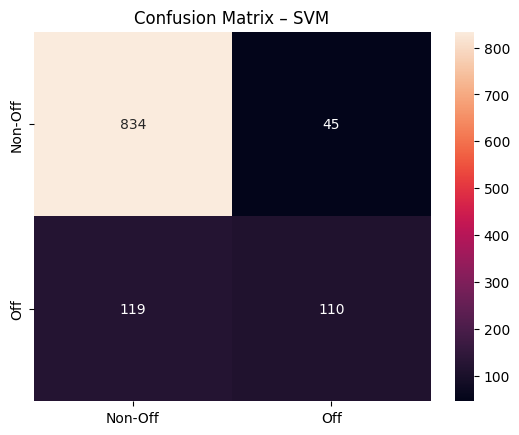

,id,text,label,dialect,clean_text,pred
4151,4152,Li rajel aw ybeyen roho mach ydir ki lmadamet ...,Offensive,Algerian,li rajel aw ybeyen roho mach ydir ki lmadamet ...,Non-Offensive
7066,7067,doula khra win labalkom balak andhom ebola wal...,Offensive,Algerian,doula khra win labalkom balak andhom ebola wal...,Non-Offensive
3929,3930,3ami agent c bon rani jayba el 3am ;) if u kno...,Offensive,Algerian,3ami agent c bon rani jayba el 3am if u know w...,Non-Offensive
7131,7132,hsab machft f ga video kayn wahdin ycomento ha...,Offensive,Algerian,hsab machft f ga video kayn wahdin ycomento ha...,Non-Offensive
3803,3804,hbibna 7acha w lilah ma9olnach tkhadmo 3andi o...,Offensive,Algerian,hbibna 7acha w lilah ma9olnach tkhadmo 3andi o...,Non-Offensive


In [ ]:
X = df["clean_text"]
y = df["label"]
dialects = df["dialect"]

X_train, X_temp, y_train, y_temp, d_train, d_temp = train_test_split(
    X, y, dialects, test_size=0.3, stratify=y, random_state=42
)

X_dev, X_test, y_dev, y_test, d_dev, d_test = train_test_split(
    X_temp, y_temp, d_temp, test_size=0.5, stratify=y_temp, random_state=42
)
# TF-IDF (mots + caractères)
tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=3,
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_dev_tfidf = tfidf.transform(X_dev)
X_test_tfidf = tfidf.transform(X_test)

#Modèles classiques
models = {
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro"
    )

    results.append([name, acc, p, r, f])

    print("\n", name)
    print(classification_report(y_test, y_pred))
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "Macro F1"]
)
results_df

#Résultats par dialecte
def eval_by_dialect(model):
    res = {}
    for dialect in ["Algerian", "Lebanese"]:
        idx = np.where(d_test.values == dialect)[0]

        X_d = X_test_tfidf[idx]
        y_true = y_test.iloc[idx]
        y_pred = model.predict(X_d)

        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        res[dialect] = f1
    return res
for name, model in models.items():
    print(name, eval_by_dialect(model))



svm = models["Linear SVM"]
y_pred = svm.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Non-Off", "Off"],
            yticklabels=["Non-Off", "Off"])
plt.title("Confusion Matrix – SVM")
plt.show()

errors = df.loc[X_test.index]
errors = errors.assign(pred=y_pred)

false_negatives = errors[
    (errors["label"] == "Offensive") &
    (errors["pred"] == "Non-Offensive")
]

false_negatives.sample(5)


In [ ]:
import numpy as np
import pandas as pd

# y_test : vraies étiquettes ("Offensive"/"Non-Offensive")
# y_pred : prédictions SVM
# d_test : dialectes sur le test ("Algerian"/"Lebanese")

def fp_fn_by_dialect(y_true, y_pred, dialects, positive_label="Offensive"):
    results = {}
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    dialects = np.array(dialects)

    for dialect in sorted(np.unique(dialects)):
        mask = dialects == dialect
        yt = y_true[mask]
        yp = y_pred[mask]

        tp = np.sum((yt == positive_label) & (yp == positive_label))
        fp = np.sum((yt != positive_label) & (yp == positive_label))
        fn = np.sum((yt == positive_label) & (yp != positive_label))
        tn = np.sum((yt != positive_label) & (yp != positive_label))

        n = len(yt)
        results[dialect] = {
            "n_exemples": int(n),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "taux_FP": fp / n if n > 0 else 0.0,
            "taux_FN": fn / n if n > 0 else 0.0,
        }
    return results

fp_fn_svm = fp_fn_by_dialect(y_test, y_pred, d_test, positive_label="Offensive")

# Affichage propre
pd.DataFrame(fp_fn_svm).T

,n_exemples,TP,FP,FN,TN,taux_FP,taux_FN
Algerian,631.0,107.0,39.0,96.0,389.0,0.061807,0.152139
Lebanese,477.0,3.0,6.0,23.0,445.0,0.012579,0.048218


**Partie 3 – Modèle BERT**

In [ ]:
pip install transformers datasets torch

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
from datasets import Dataset

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")

# Label mapping
label_map = {"Non-Offensive": 0, "Offensive": 1}

# HuggingFace datasets
train_ds = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": [label_map[l] for l in y_train]
})

test_ds = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": [label_map[l] for l in y_test]
})

# Tokenization SANS padding
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds = test_ds.map(tokenize, batched=True, remove_columns=["text"])

#Data collator (padding dynamique)
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest"
)

# Model
model = AutoModelForSequenceClassification.from_pretrained(
    "alger-ia/dziribert",
    num_labels=2
)

# Training arguments
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator
)

# Train
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5168 [00:00<?, ? examples/s]

Map:   0%|          | 0/1108 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at alger-ia/dziribert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3407689850.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.322300,0.332478
2,0.196700,0.393787
3,0.082800,0.546187


TrainOutput(global_step=969, training_loss=0.21604535085128926, metrics={'train_runtime': 230.6583, 'train_samples_per_second': 67.216, 'train_steps_per_second': 4.201, 'total_flos': 471223677929280.0, 'train_loss': 0.21604535085128926, 'epoch': 3.0})

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
       'train_runtime', 'train_samples_per_second', 'train_steps_per_second',
       'total_flos', 'train_loss'],
      dtype='object')


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.4508,5.350742,0.000019,0.154799,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.3163,14.554210,0.000018,0.309598,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.3682,11.308630,0.000017,0.464396,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.3146,5.988392,0.000016,0.619195,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.3185,6.772111,0.000015,0.773994,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


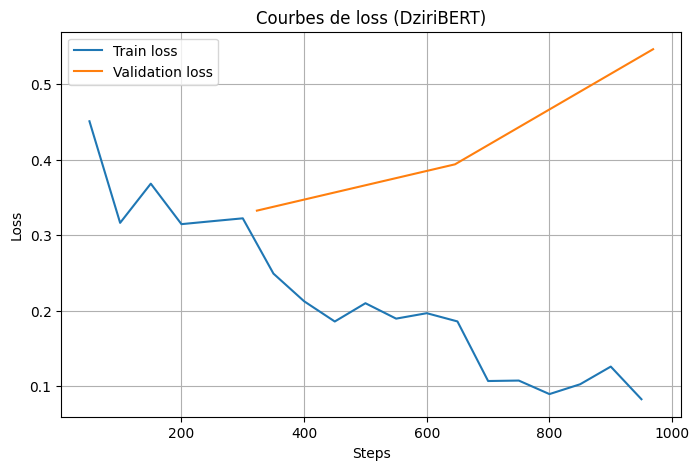

In [ ]:
# Récupérer l'historique de training du Trainer
logs = pd.DataFrame(trainer.state.log_history)

# Afficher les différentes colonnes disponibles
print(logs.columns)
display(logs.head())

# Courbe de loss (train vs validation)
plt.figure(figsize=(8, 5))

# Loss d'entraînement
train_loss = logs[logs["loss"].notna()][["step", "loss"]]
plt.plot(train_loss["step"], train_loss["loss"], label="Train loss")

# Loss de validation (eval_loss)
eval_loss = logs[logs["eval_loss"].notna()][["step", "eval_loss"]]
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Courbes de loss (DziriBERT)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Prédictions BERT
preds = trainer.predict(test_ds)
y_pred_bert = np.argmax(preds.predictions, axis=1)

y_true = y_test.map({"Non-Offensive": 0, "Offensive": 1}).values

# Scores globaux
acc_bert = accuracy_score(y_true, y_pred_bert)
p_bert, r_bert, f1_bert, _ = precision_recall_fscore_support(
    y_true, y_pred_bert, average="macro"
)

print("DziriBERT - Global")
print("Accuracy :", acc_bert)
print("Precision:", p_bert)
print("Recall   :", r_bert)
print("Macro F1 :", f1_bert)

DziriBERT - Global
Accuracy : 0.868231046931408
Precision: 0.8031198939810847
Recall   : 0.7829411151020165
Macro F1 : 0.7922759655043119


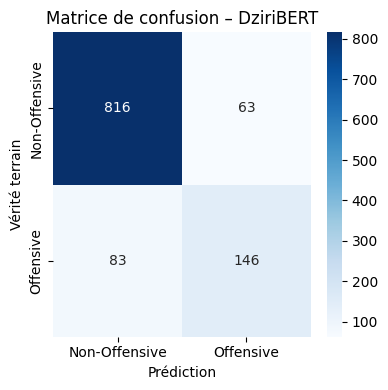

In [ ]:
cm_bert = confusion_matrix(y_true, y_pred_bert)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    xticklabels=["Non-Offensive", "Offensive"],
    yticklabels=["Non-Offensive", "Offensive"],
    cmap="Blues"
)
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.title("Matrice de confusion – DziriBERT")
plt.tight_layout()
plt.show()

In [ ]:
id2label = {0: "Non-Offensive", 1: "Offensive"}
y_pred_bert_labels = np.array([id2label[i] for i in y_pred_bert])

y_test_labels = np.array(y_test.values)


def fp_fn_by_dialect(y_true, y_pred, dialects, positive_label="Offensive"):
    results = {}
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    dialects = np.array(dialects)

    for dialect in sorted(np.unique(dialects)):
        mask = dialects == dialect
        yt = y_true[mask]
        yp = y_pred[mask]

        tp = np.sum((yt == positive_label) & (yp == positive_label))
        fp = np.sum((yt != positive_label) & (yp == positive_label))
        fn = np.sum((yt == positive_label) & (yp != positive_label))
        tn = np.sum((yt != positive_label) & (yp != positive_label))

        n = len(yt)
        results[dialect] = {
            "n_exemples": int(n),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "taux_FP": fp / n if n > 0 else 0.0,
            "taux_FN": fn / n if n > 0 else 0.0,
        }
    return results

fp_fn_bert = fp_fn_by_dialect(y_test_labels, y_pred_bert_labels, d_test, positive_label="Offensive")

# Affichage
pd.DataFrame(fp_fn_bert).T

,n_exemples,TP,FP,FN,TN,taux_FP,taux_FN
Algerian,631.0,143.0,55.0,60.0,373.0,0.087163,0.095087
Lebanese,477.0,3.0,8.0,23.0,443.0,0.016771,0.048218


In [ ]:
id2label = {0: "Non-Offensive", 1: "Offensive"}
y_pred_bert_labels = np.array([id2label[i] for i in y_pred_bert])

y_test_labels = np.array(y_test.values)      # "Offensive"/"Non-Offensive"
d_test_array = np.array(d_test.values)       # "Algerian"/"Lebanese"

errors_bert = df.loc[X_test.index].copy()
errors_bert["pred_bert"] = y_pred_bert_labels

#Faux négatifs BERT
false_negatives_bert = errors_bert[
    (errors_bert["label"] == "Offensive") &
    (errors_bert["pred_bert"] == "Non-Offensive")
]

# Afficher des exemples
false_negatives_bert[["id", "text", "label", "dialect", "pred_bert"]].sample(
    5, random_state=42
)

,id,text,label,dialect,pred_bert
3768,3769,Saha chkon fikom li chaf hadik laktiba li rahi...,Offensive,Algerian,Non-Offensive
5136,5137,Khessara 3liik kho ndjii bach nechof mertek w ...,Offensive,Algerian,Non-Offensive
5551,5552,Wch d5l crb dok ana wa9il ani ntnaQ f l39l,Offensive,Algerian,Non-Offensive
7189,7190,lazam yakharjo malblad,Offensive,Algerian,Non-Offensive
4030,4031,nn médéa for eu haja miykhesna fiha hadi hiya ...,Offensive,Algerian,Non-Offensive


In [ ]:
#COMPARAISON DES SCORES GLOBAUX
comparison = results_df.copy()
comparison.loc[len(comparison)] = [
    "DziriBERT",
    acc_bert,
    p_bert,
    r_bert,
    f1_bert
]

comparison


,Model,Accuracy,Precision,Recall,Macro F1
0,Multinomial NB,0.842960,0.804579,0.662066,0.694795
1,Complement NB,0.753610,0.676272,0.739762,0.688358
2,Logistic Regression,0.849278,0.866902,0.649902,0.685987
3,Linear SVM,0.851986,0.792404,0.714577,0.741699
4,Random Forest,0.849278,0.843675,0.659590,0.695812
5,DziriBERT,0.868231,0.803120,0.782941,0.792276


In [ ]:
def eval_bert_by_dialect(dialect_name):
    idx = np.where(d_test.values == dialect_name)[0]

    y_true_d = y_true[idx]
    y_pred_d = y_pred_bert[idx]

    _, _, f1, _ = precision_recall_fscore_support(
        y_true_d, y_pred_d, average="macro", zero_division=0
    )
    return f1

print("DziriBERT Algerian F1:", eval_bert_by_dialect("Algerian"))
print("DziriBERT Lebanese F1:", eval_bert_by_dialect("Lebanese"))

for name, model in models.items():
    print(name, eval_by_dialect(model))

print("DziriBERT:", {
    "Algerian": eval_bert_by_dialect("Algerian"),
    "Lebanese": eval_bert_by_dialect("Lebanese")
})

DziriBERT Algerian F1: 0.7898256681177428
DziriBERT Lebanese F1: 0.5641781366972207
Multinomial NB {'Algerian': 0.6807254895968107, 'Lebanese': 0.5235526788924847}
Complement NB {'Algerian': 0.6153142717795526, 'Lebanese': 0.5360605971292994}
Logistic Regression {'Algerian': 0.6803444782168186, 'Lebanese': 0.4854368932038835}
Linear SVM {'Algerian': 0.732658165875275, 'Lebanese': 0.5699362661277786}
Random Forest {'Algerian': 0.6940736938170203, 'Lebanese': 0.5134734971868522}
DziriBERT: {'Algerian': 0.7898256681177428, 'Lebanese': 0.5641781366972207}


In [ ]:
df_test = df.loc[X_test.index].copy()

df_test["pred_svm"] = y_pred
df_test["pred_bert"] = y_pred_bert_labels


In [ ]:
#Cas où SVM réussit et BERT échoue
svm_ok_bert_ko = df_test[
    (df_test["label"] == df_test["pred_svm"]) &
    (df_test["label"] != df_test["pred_bert"])
]

# Voir quelques exemples
svm_ok_bert_ko[["text", "label", "pred_svm", "pred_bert", "dialect"]].sample(10, random_state=0)

,text,label,pred_svm,pred_bert,dialect
7004,awnohom hada howa islam,Non-Offensive,Non-Offensive,Offensive,Algerian
268,@lordmarocain1 toooooooooooooooz lech maraja3t...,Offensive,Offensive,Non-Offensive,Lebanese
3474,Kon ja 3andk khok fel7abs ma tahderhach adi lh...,Non-Offensive,Non-Offensive,Offensive,Algerian
4576,hhhhhhhhhhh cha3b hbal walah aa 3arg lalsan ma...,Non-Offensive,Non-Offensive,Offensive,Algerian
7274,rak neya rseau trafiquants yakhadmou blouled s...,Non-Offensive,Non-Offensive,Offensive,Algerian
1968,@kevo_90 tsk 3ayb,Non-Offensive,Non-Offensive,Offensive,Lebanese
7126,hna dèja mkewda lina zwamel,Non-Offensive,Non-Offensive,Offensive,Algerian
2164,ayre ktir 2asarit fiye hal kahbriye,Offensive,Offensive,Non-Offensive,Lebanese
609,enta 🐑🐑🐑,Non-Offensive,Non-Offensive,Offensive,Lebanese
7189,lazam yakharjo malblad,Offensive,Offensive,Non-Offensive,Algerian


In [ ]:
#Cas où BERT réussit et SVM échoue
bert_ok_svm_ko = df_test[
    (df_test["label"] == df_test["pred_bert"]) &
    (df_test["label"] != df_test["pred_svm"])
]

bert_ok_svm_ko[["text", "label", "pred_svm", "pred_bert", "dialect"]].sample(10, random_state=0)

,text,label,pred_svm,pred_bert,dialect
2718,Kil ma esma3 rannit inno woselne email mnil je...,Non-Offensive,Offensive,Non-Offensive,Lebanese
6606,Wla tkun kima anouch mafia,Offensive,Non-Offensive,Offensive,Algerian
6705,3lah matrohch tkawed ah chakam ga3 l 3am w nta...,Offensive,Non-Offensive,Offensive,Algerian
5942,your one of them tsem3ili bondo9ia,Non-Offensive,Offensive,Non-Offensive,Algerian
6256,Nas nas,Non-Offensive,Offensive,Non-Offensive,Algerian
1922,Chou ghalat bl vedio???,Non-Offensive,Offensive,Non-Offensive,Lebanese
5209,Hhhhhhh mrc khtiti ###### kayane zine f bladna...,Non-Offensive,Offensive,Non-Offensive,Algerian
6916,N3ebdou matoub khir ma n3ebdou wlid lqaf ta3 b...,Offensive,Non-Offensive,Offensive,Algerian
7252,ntu reçois,Offensive,Non-Offensive,Offensive,Algerian
5929,Ch7al fi omrek hbibi?,Non-Offensive,Offensive,Non-Offensive,Algerian
